In [1]:
# ============================================================
#  KNN Classification Assignment
#  Dataset: Iris (loaded directly from GitHub)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ── Load directly from GitHub raw URL (no manual upload needed) ──
URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

df = pd.read_csv(URL)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head(10)

Dataset loaded successfully!
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [3]:
print("="*50)
print("DATASET INFO")
print("="*50)
print(df.info())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['species'].value_counts())
print("\nStatistical Summary:")
df.describe()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Data Types:
 sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Missing Values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class Distribution:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


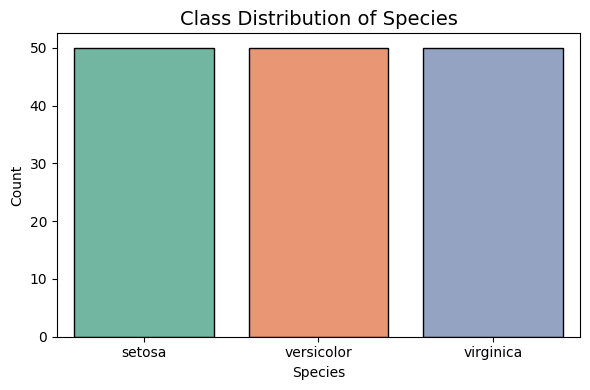

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='species', data=df, palette='Set2', edgecolor='black')
plt.title('Class Distribution of Species', fontsize=14)
plt.xlabel('Species')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

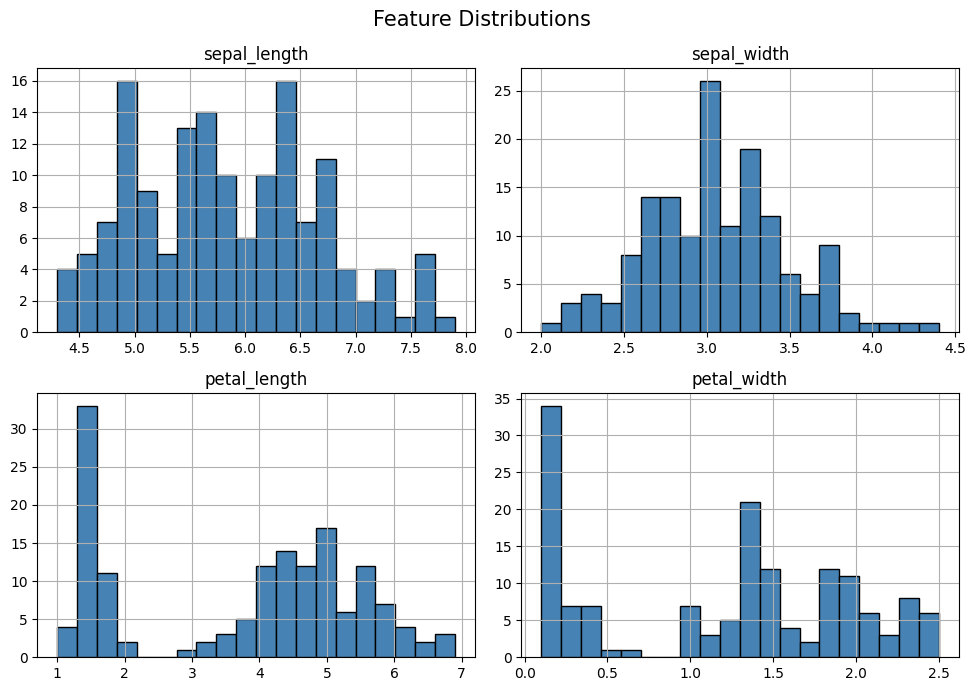

In [5]:
df.drop('species', axis=1).hist(figsize=(10, 7), bins=20,
                                 color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=15)
plt.tight_layout()
plt.show()

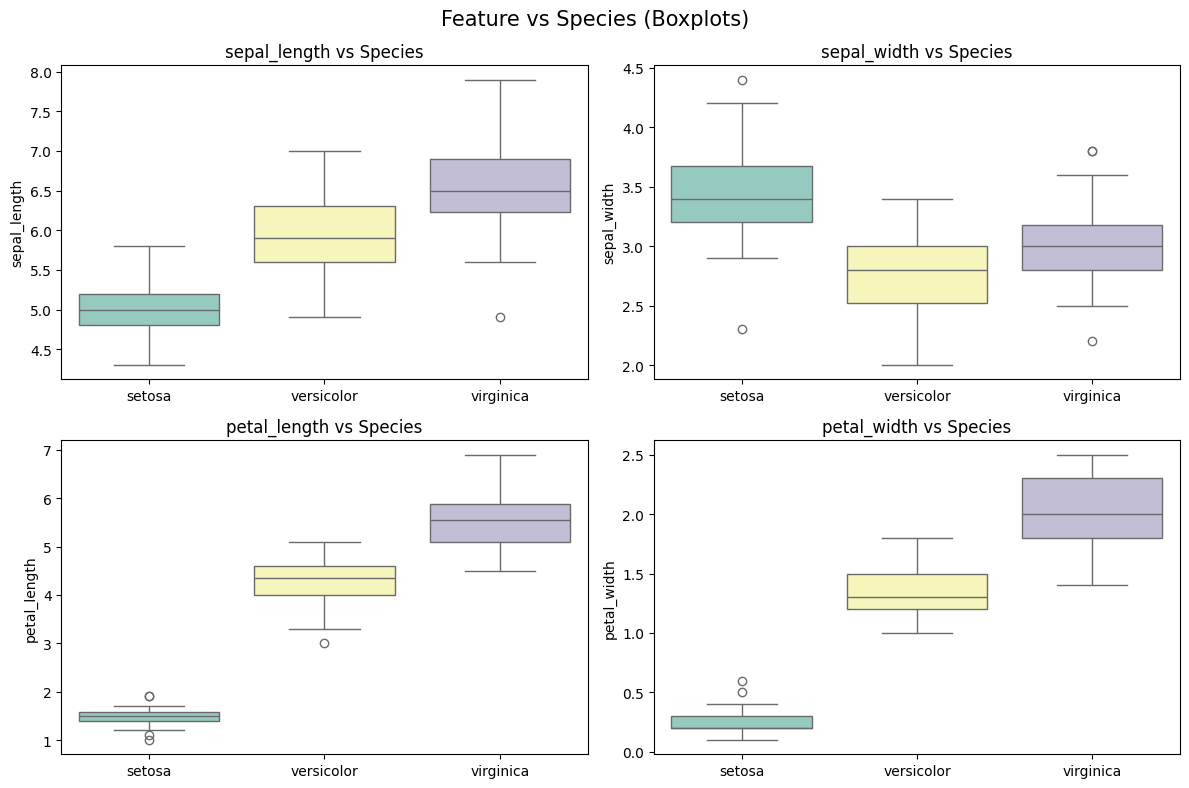

In [6]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(x='species', y=feat, data=df, ax=axes[i], palette='Set3')
    axes[i].set_title(f'{feat} vs Species', fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('Feature vs Species (Boxplots)', fontsize=15)
plt.tight_layout()
plt.show()

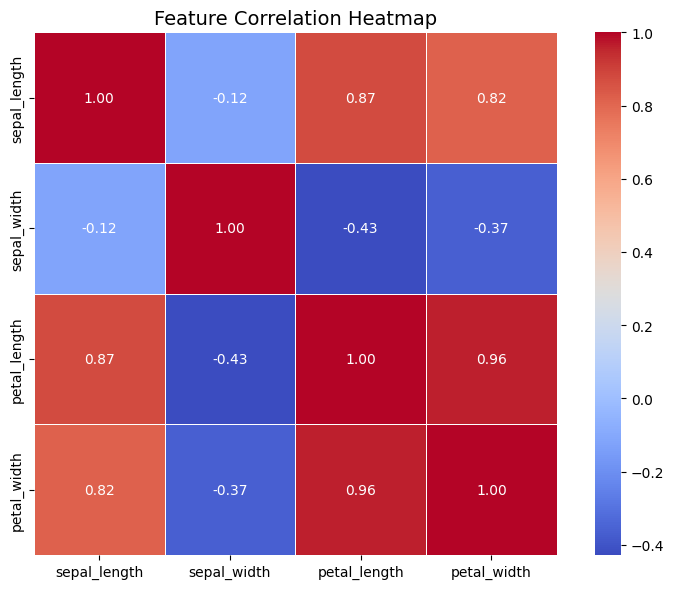

In [7]:
plt.figure(figsize=(8, 6))
corr = df.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

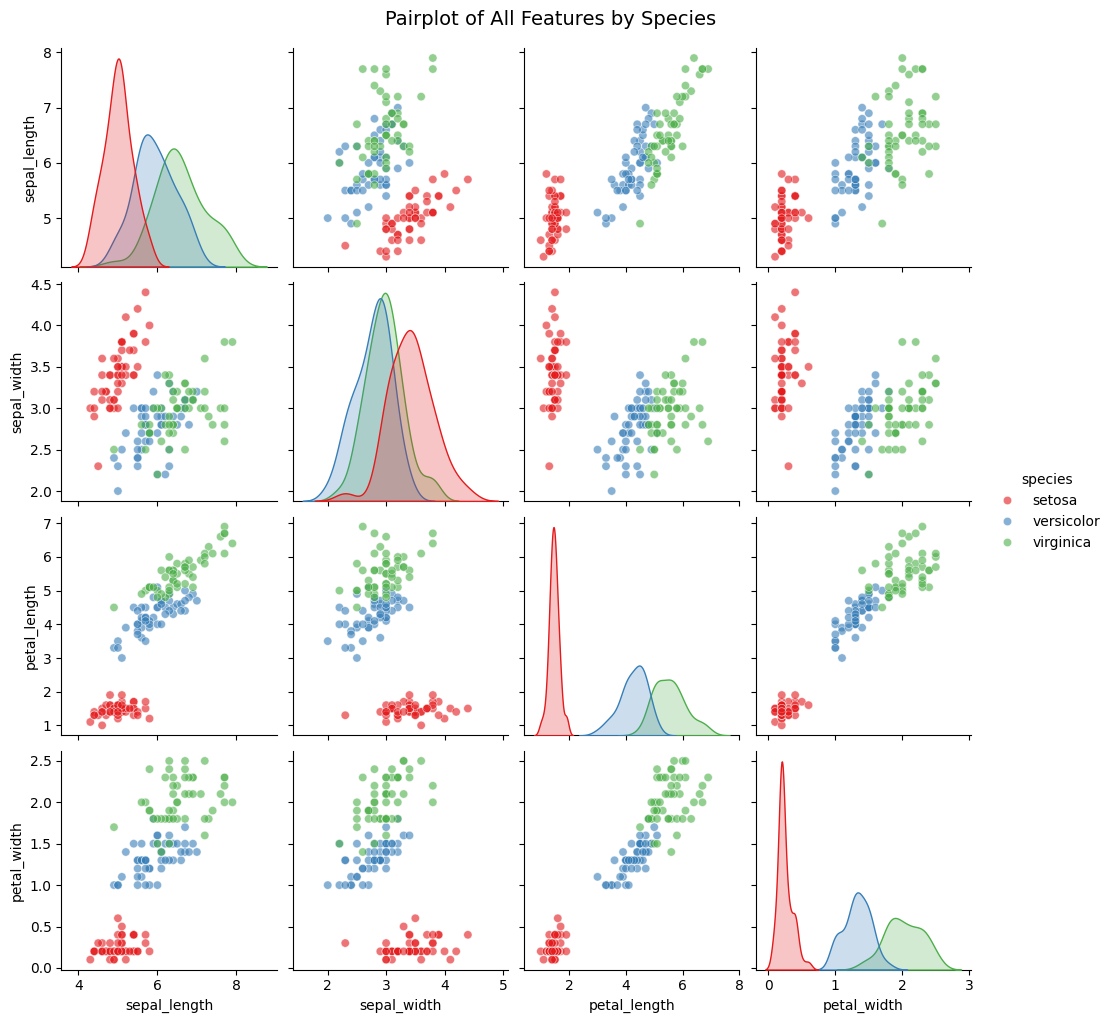

In [8]:
sns.pairplot(df, hue='species', palette='Set1',
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of All Features by Species', y=1.02, fontsize=14)
plt.show()

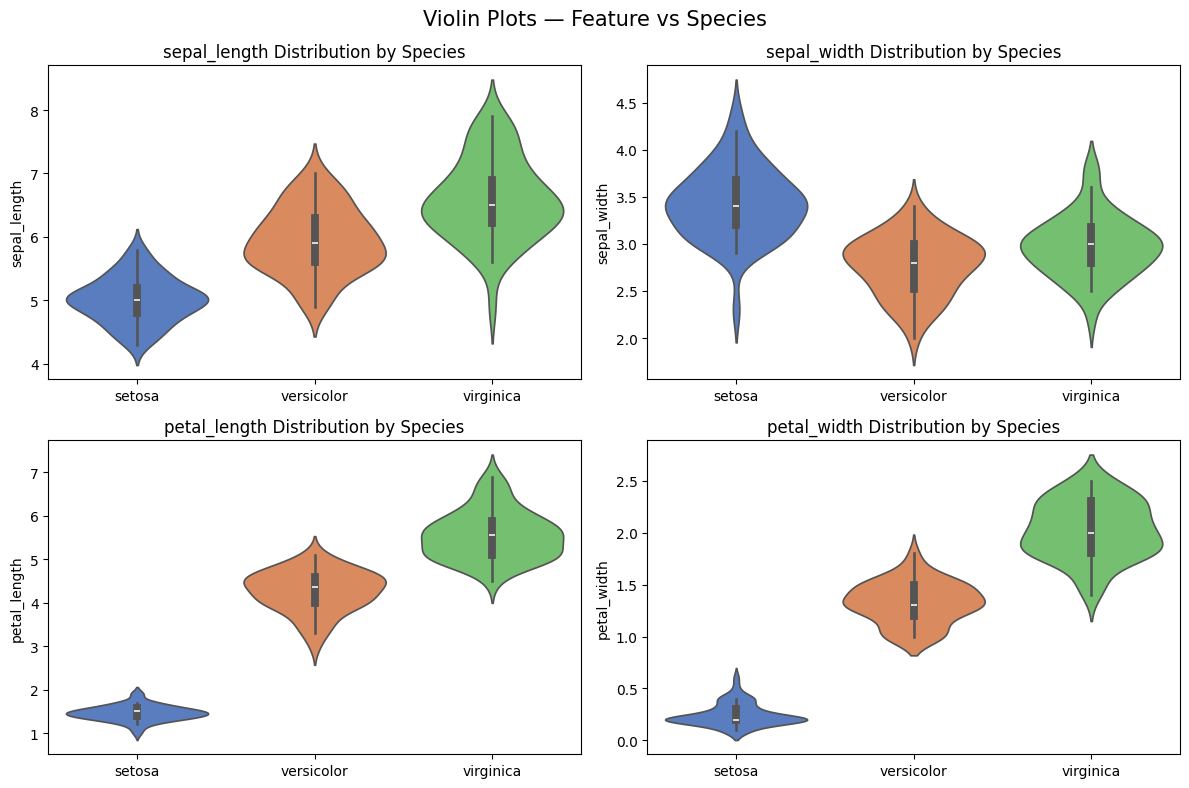

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.violinplot(x='species', y=feat, data=df, ax=axes[i], palette='muted')
    axes[i].set_title(f'{feat} Distribution by Species')
    axes[i].set_xlabel('')

plt.suptitle('Violin Plots — Feature vs Species', fontsize=15)
plt.tight_layout()
plt.show()

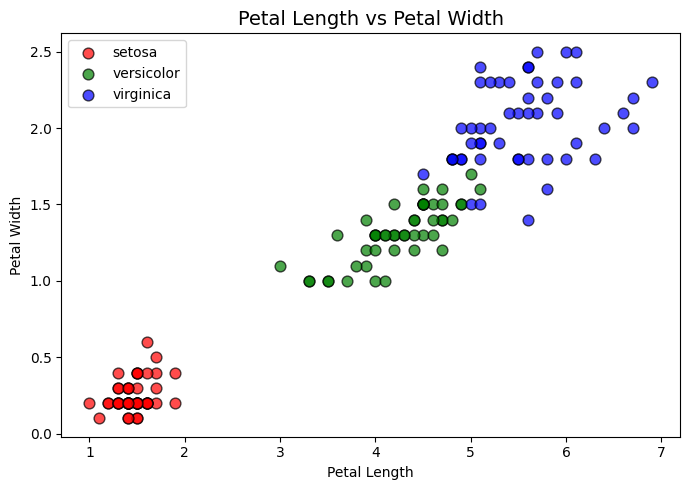

In [10]:
plt.figure(figsize=(7, 5))
colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}
for species, group in df.groupby('species'):
    plt.scatter(group['petal_length'], group['petal_width'],
                label=species, color=colors[species], alpha=0.7, edgecolors='k', s=60)

plt.title('Petal Length vs Petal Width', fontsize=14)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# ── Encode target labels ──
le = LabelEncoder()
df['target'] = le.fit_transform(df['species'])
print("Label Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df[features].values
y = df['target'].values

# ── Train / Validation / Test Split (70 / 15 / 15) ──
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# ── Standardize (critical for KNN!) ──
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"\nTrain : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

Label Mapping: {'setosa': np.int64(0), 'versicolor': np.int64(1), 'virginica': np.int64(2)}

Train : (105, 4)
Val   : (22, 4)
Test  : (23, 4)


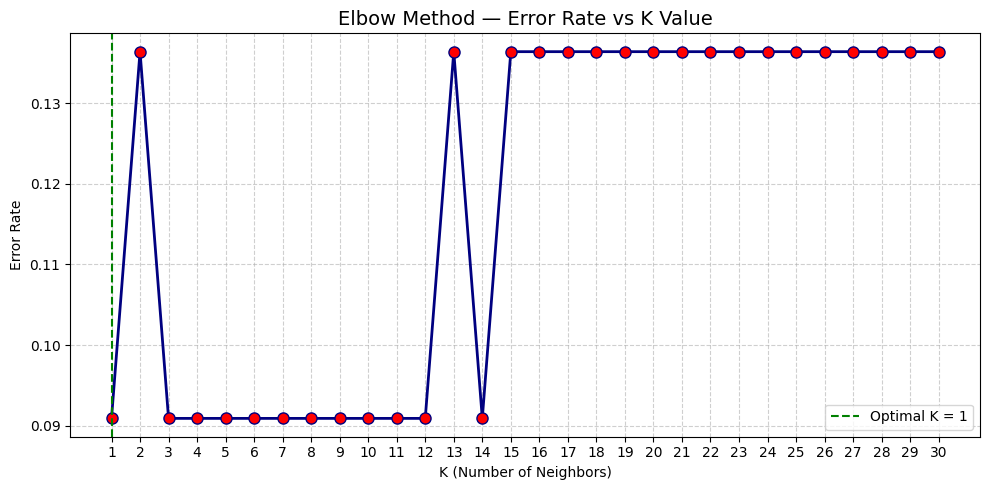

Optimal K from Elbow: 1


In [12]:
error_rates = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_val)
    error_rates.append(1 - accuracy_score(y_val, preds))

# ── Plot ──
plt.figure(figsize=(10, 5))
plt.plot(k_range, error_rates, color='navy', marker='o',
         markerfacecolor='red', markersize=8, linewidth=2)
plt.title('Elbow Method — Error Rate vs K Value', fontsize=14)
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Error Rate')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
optimal_k = k_range[np.argmin(error_rates)]
plt.axvline(x=optimal_k, color='green', linestyle='--', label=f'Optimal K = {optimal_k}')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Optimal K from Elbow: {optimal_k}")

In [13]:
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['minkowski', 'euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid,
                    cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("\nBest Parameters :", grid.best_params_)
print("Best CV Accuracy :", round(grid.best_score_, 4))
best_knn = grid.best_estimator_

Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best Parameters : {'metric': 'minkowski', 'n_neighbors': 14, 'weights': 'uniform'}
Best CV Accuracy : 0.9714


In [14]:
y_pred  = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)

print("="*45)
print("       TEST SET EVALUATION METRICS")
print("="*45)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"  AUC (OvR) : {roc_auc_score(y_test, y_proba, multi_class='ovr'):.4f}")
print("="*45)
print("\nFull Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

       TEST SET EVALUATION METRICS
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
  AUC (OvR) : 1.0000

Full Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       1.00      1.00      1.00         8
   virginica       1.00      1.00      1.00         8

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



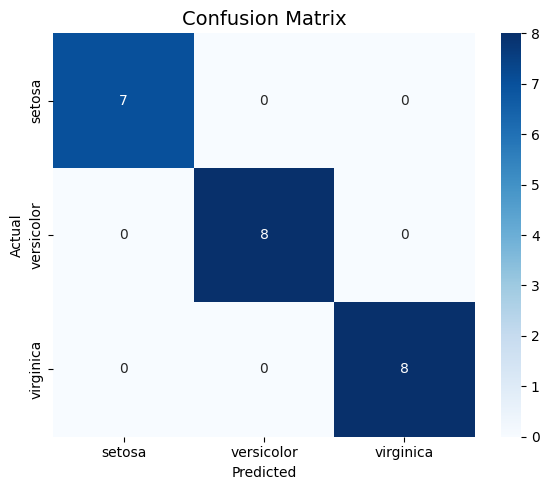

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

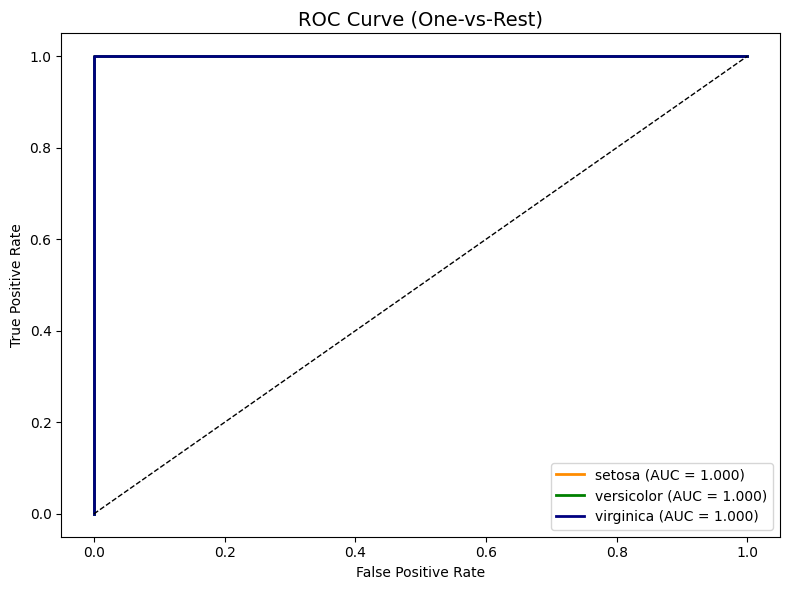

In [16]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors = ['darkorange', 'green', 'navy']

plt.figure(figsize=(8, 6))
for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {auc:.3f})')

plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

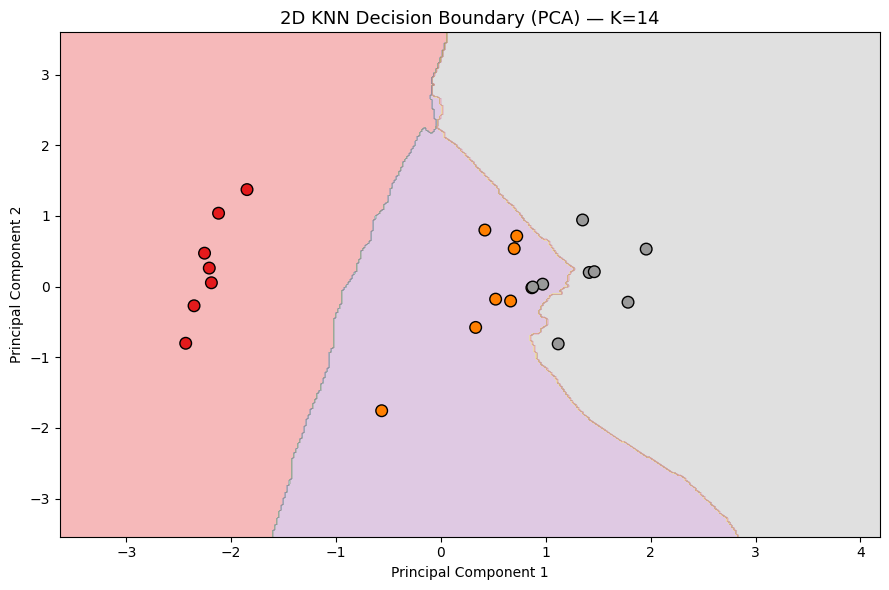

In [17]:
# Reduce to 2D with PCA
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d  = pca.transform(X_test)

# Train KNN on 2D
knn_2d = KNeighborsClassifier(**grid.best_params_)
knn_2d.fit(X_train_2d, y_train)

# Build mesh grid
h = 0.02
x_min, x_max = X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1
y_min, y_max = X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
scatter = plt.scatter(X_test_2d[:,0], X_test_2d[:,1],
                      c=y_test, cmap='Set1', edgecolors='k', s=70)
plt.title(f'2D KNN Decision Boundary (PCA) — K={grid.best_params_["n_neighbors"]}', fontsize=13)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

In [18]:
results = pd.DataFrame({
    'Actual'         : le.inverse_transform(y_test),
    'Predicted'      : le.inverse_transform(y_pred),
    'Prob_setosa'    : y_proba[:,0].round(3),
    'Prob_versicolor': y_proba[:,1].round(3),
    'Prob_virginica' : y_proba[:,2].round(3),
    'Correct'        : y_test == y_pred
})
print(results.head(15).to_string(index=False))

    Actual  Predicted  Prob_setosa  Prob_versicolor  Prob_virginica  Correct
    setosa     setosa          1.0            0.000           0.000     True
    setosa     setosa          1.0            0.000           0.000     True
 virginica  virginica          0.0            0.429           0.571     True
versicolor versicolor          0.0            1.000           0.000     True
 virginica  virginica          0.0            0.429           0.571     True
 virginica  virginica          0.0            0.000           1.000     True
versicolor versicolor          0.0            0.929           0.071     True
 virginica  virginica          0.0            0.071           0.929     True
    setosa     setosa          1.0            0.000           0.000     True
versicolor versicolor          0.0            0.714           0.286     True
versicolor versicolor          0.0            0.857           0.143     True
    setosa     setosa          1.0            0.000           0.000     True